# Sprint 34 — Streaming/buffer & Q15 pour Mahalanobis

Deux volets :
- **Partie A — Streaming** : débit temps-réel et marge avant saturation pour un flux capteur
  (rate × stride × fenêtre), modèles EWC et Mahalanobis embarqués.
- **Partie B — Q15 Mahalanobis** : `sigma_inv_` en **int16 Q15** comme fallback de l'INT8 (réponse au
  `TODO(arnaud)` : INT8 collapse sur grande dynamique de Σ⁻¹). On mesure la **récupération d'AUROC** et
  la **fidélité de rang** au FP32, puis la parité board.

**Source de vérité** :
- A : `experiments/exp_S34_streaming/{model}_rate{R}_stride{S}_w5.json` + `summary_{model}_w5.json` + `bss_by_window.json`
- B : `experiments/exp_S34_maha_q15/summary.json` (+ `{ds}_{fp32,int8,q15}.json`) + `exp_S34_board_maha_q15/summary.json`


In [1]:
import json, sys, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists()
EXP = ROOT / "experiments"
print("ROOT =", ROOT)

ROOT = /home/leonard/Documents/ENAC/cl-embedded


## Partie A — Streaming
### A.1 Chargement des configurations rate × stride

In [2]:
rows = []
for f in sorted((EXP / "exp_S34_streaming").glob("*rate*_stride*_w*.json")):
    rows.append(json.loads(f.read_text()))
st = pd.DataFrame(rows)
print("Configs streaming :", len(st), "| modèles:", sorted(st.model.unique()),
      "| rates:", sorted(st.rate_hz.unique()), "| strides:", sorted(st.stride.unique()))
st.head()

Configs streaming : 42 | modèles: ['ewc', 'mahalanobis'] | rates: [np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000)] | strides: [np.int64(1), np.int64(2), np.int64(5)]


,model,rate_hz,stride,window,n_sent,n_received,latence_dwt_us,latence_dwt_p99_us,drops,timeouts,crc_errors,bss_bytes,debit_streaming_hz,debit_max_hz,marge_pct,saturation_predite,saturation_observee,saturation_atteinte
0,ewc,1000,1,5,60,60,50.0,50.0,0,0,0,104956,200.0,20000.0,0.990,False,False,False
1,ewc,1000,2,5,60,60,50.0,50.0,0,0,0,104956,400.0,20000.0,0.980,False,False,False
2,ewc,1000,5,5,60,60,50.0,50.0,0,0,0,104956,1000.0,20000.0,0.950,False,False,False
3,ewc,100,1,5,60,60,50.0,50.0,0,0,0,104956,20.0,20000.0,0.999,False,False,False
4,ewc,100,2,5,60,60,50.0,50.0,0,0,0,104956,40.0,20000.0,0.998,False,False,False


### A.2 Débit streaming & marge temps-réel vs (rate, stride)

Heatmaps par modèle : débit effectif (Hz) et marge avant saturation (`marge_pct`). Plus la marge est
proche de 1, plus le système est loin de la saturation.

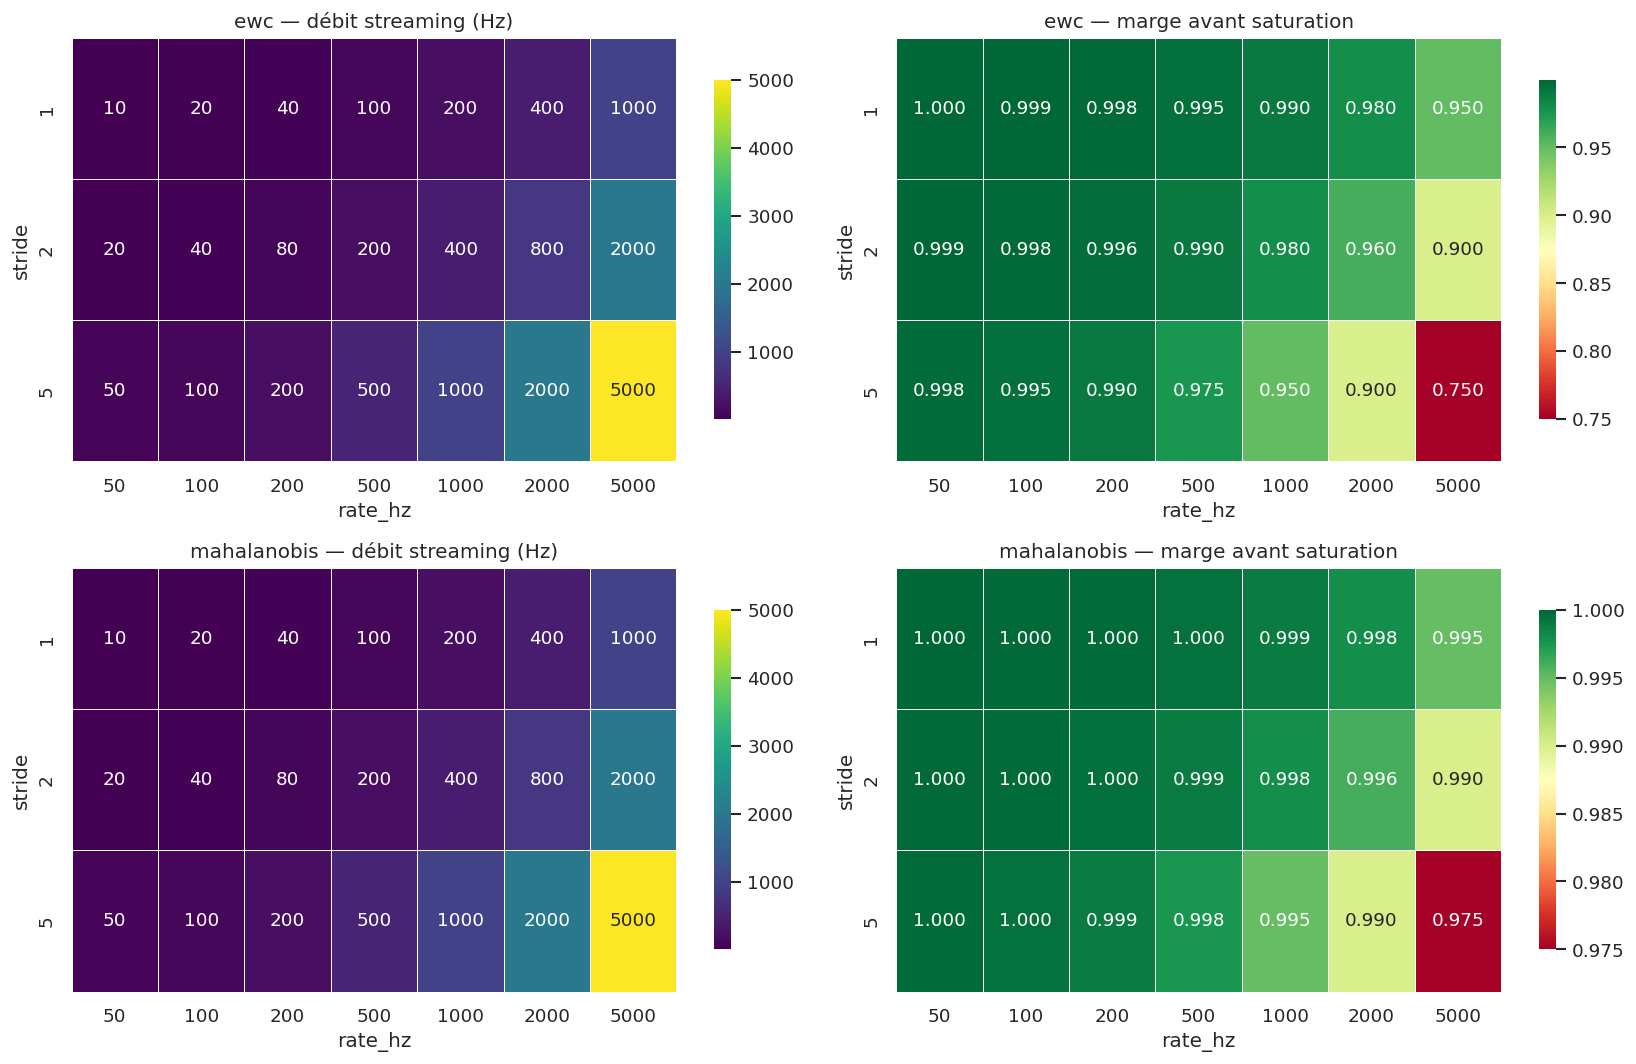

In [3]:
models = sorted(st.model.unique())
fig, axes = plt.subplots(len(models), 2, figsize=(14, 4.5 * len(models)))
if len(models) == 1:
    axes = axes.reshape(1, -1)
for i, m in enumerate(models):
    sub = st[st.model == m]
    for ax, (col, cmap, fmt, title) in zip(axes[i], [
            ("debit_streaming_hz", "viridis", ".0f", "débit streaming (Hz)"),
            ("marge_pct", "RdYlGn", ".3f", "marge avant saturation")]):
        piv = sub.pivot_table(index="stride", columns="rate_hz", values=col)
        sns.heatmap(piv, annot=True, fmt=fmt, cmap=cmap, ax=ax, linewidths=.5, cbar_kws={"shrink": .8})
        ax.set_title(f"{m} — {title}"); ax.set_xlabel("rate_hz"); ax.set_ylabel("stride")
plt.tight_layout(); plt.show()

### A.3 Débit max théorique vs débit demandé — où est la saturation ?

`debit_max_hz` = 1/latence inférence (capacité). `debit_streaming_hz` = débit effectif demandé.
Aucune saturation observée tant que le débit demandé reste sous la capacité.

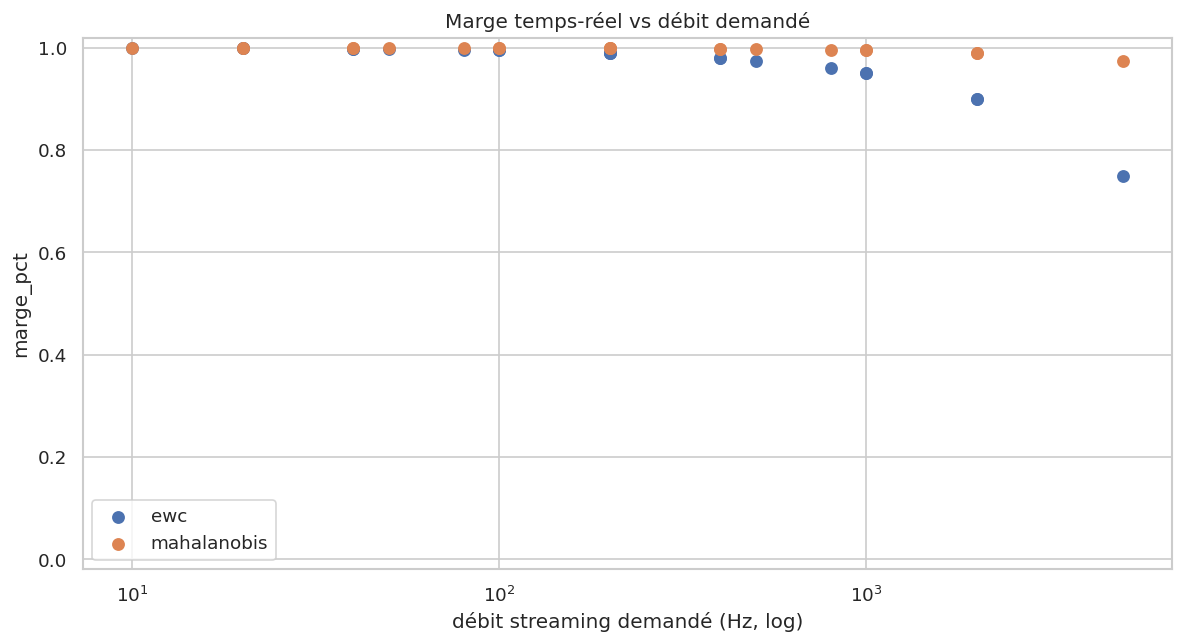

Configurations avec saturation observée : 0 / 42
Débit max (capacité inférence) par modèle : {'ewc': 20000.0, 'mahalanobis': 200000.0}


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for m in models:
    sub = st[st.model == m].sort_values("debit_streaming_hz")
    ax.scatter(sub["debit_streaming_hz"], sub["marge_pct"], label=f"{m}", s=45)
ax.set_xscale("log"); ax.set_xlabel("débit streaming demandé (Hz, log)")
ax.set_ylabel("marge_pct"); ax.set_title("Marge temps-réel vs débit demandé")
sat = st[st.saturation_observee == True]
ax.set_ylim(min(0, st.marge_pct.min()) - 0.02, 1.02)
ax.legend()
plt.tight_layout(); plt.show()
print("Configurations avec saturation observée :", len(sat), "/", len(st))
print("Débit max (capacité inférence) par modèle :",
      st.groupby("model")["debit_max_hz"].first().to_dict())

### A.4 Coût mémoire du buffer de streaming par fenêtre

`stream_buf = W × PROTO_MAX_N(16) × 4 octets`. La `.bss` croît linéairement avec la taille de fenêtre.

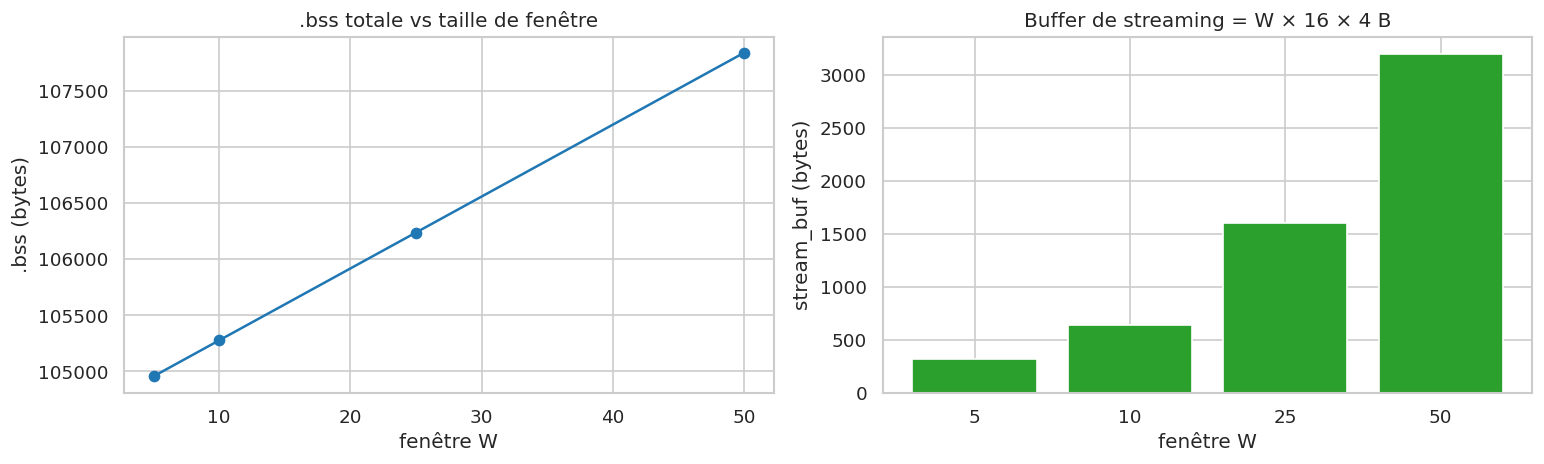

,window,bss_bytes,stream_buf_bytes,budget_64k_pct,budget_192k_pct
0,5,104956,320,160.2,53.4
1,10,105276,640,160.6,53.5
2,25,106236,1600,162.1,54.0
3,50,107836,3200,164.5,54.8


In [5]:
bw = pd.DataFrame(json.loads((EXP / "exp_S34_streaming" / "bss_by_window.json").read_text())["by_window"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(bw["window"], bw["bss_bytes"], "o-", color="#1f77b4")
ax1.set_xlabel("fenêtre W"); ax1.set_ylabel(".bss (bytes)")
ax1.set_title(".bss totale vs taille de fenêtre")
ax2.bar(bw["window"].astype(str), bw["stream_buf_bytes"], color="#2ca02c")
ax2.set_xlabel("fenêtre W"); ax2.set_ylabel("stream_buf (bytes)")
ax2.set_title("Buffer de streaming = W × 16 × 4 B")
plt.tight_layout(); plt.show()
bw

## Partie B — Q15 Mahalanobis
### B.1 AUROC : FP32 vs INT8 vs Q15 (récupération sur grande dynamique de Σ⁻¹)

In [6]:
qsum = json.loads((EXP / "exp_S34_maha_q15" / "summary.json").read_text())
q = pd.DataFrame(qsum["datasets"])
q["corr_int8"] = q["score_fidelity"].apply(lambda d: d["int8"]["corr_with_fp32"])
q["corr_q15"]  = q["score_fidelity"].apply(lambda d: d["q15"]["corr_with_fp32"])
q["ram_fp32"]  = q["ram_bytes"].apply(lambda d: d["fp32"])
q["ram_int8"]  = q["ram_bytes"].apply(lambda d: d["int8"])
q["ram_q15"]   = q["ram_bytes"].apply(lambda d: d["q15"])
DELTA = qsum.get("delta_threshold", 0.02)
print("Seuil de tolérance ΔAUROC :", DELTA)
q[["dataset", "auroc_fp32", "auroc_int8", "auroc_q15",
   "delta_int8_vs_fp32", "delta_q15_vs_fp32",
   "q15_recovers_auroc", "q15_rank_fidelity_better_than_int8"]].round(4)

Seuil de tolérance ΔAUROC : 0.02


,dataset,auroc_fp32,auroc_int8,auroc_q15,delta_int8_vs_fp32,delta_q15_vs_fp32,q15_recovers_auroc,q15_rank_fidelity_better_than_int8
0,cwru,0.4750,0.2387,0.2008,-0.2363,-0.2742,False,True
1,pronostia,0.8603,0.7469,0.8729,-0.1133,0.0127,True,True
2,monitoring,0.9725,0.9726,0.9725,0.0001,0.0000,True,True
3,cmapss,0.6551,0.6396,0.6604,-0.0154,0.0053,True,True
4,paderborn,NaN,NaN,NaN,NaN,NaN,None,True


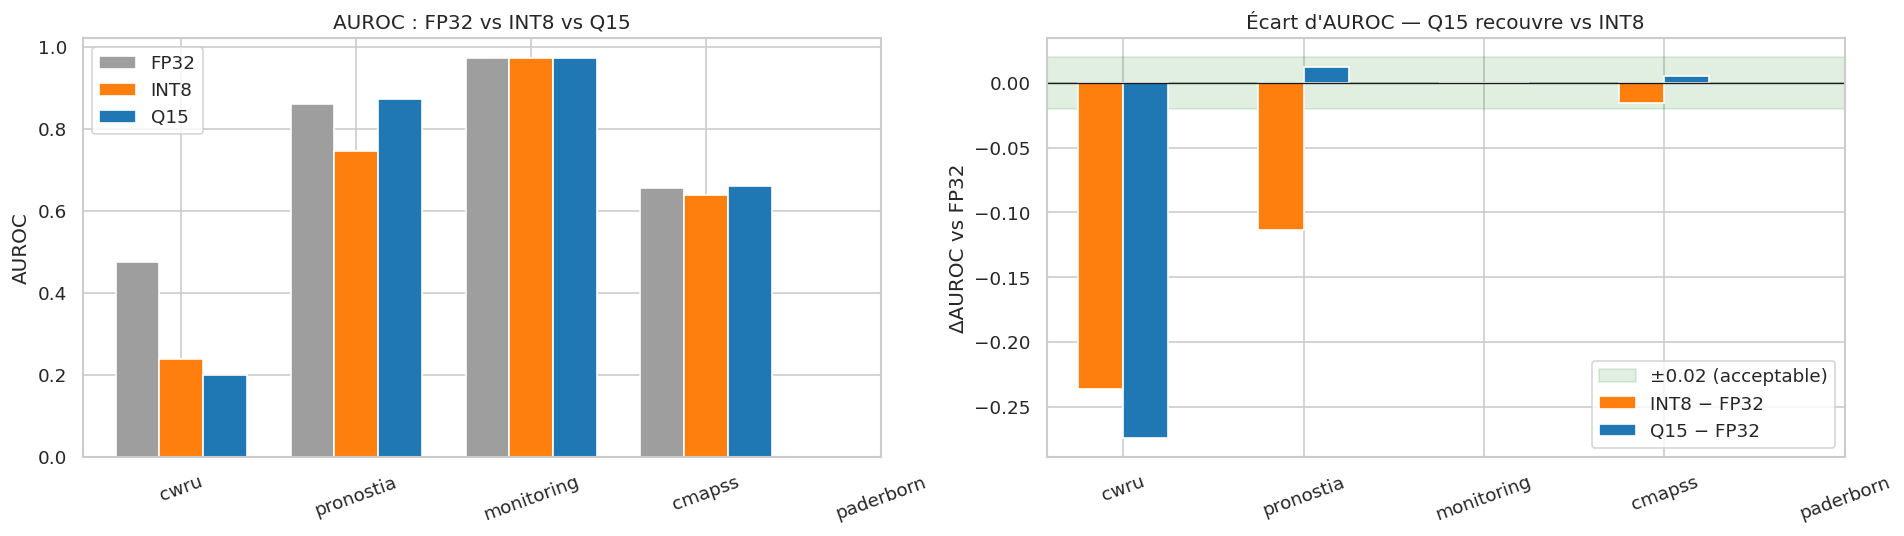

In [7]:
dsets = q["dataset"].tolist()
x = np.arange(len(dsets)); w = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.6))
ax1.bar(x - w, q["auroc_fp32"], w, label="FP32", color="#9e9e9e")
ax1.bar(x,     q["auroc_int8"], w, label="INT8", color="#ff7f0e")
ax1.bar(x + w, q["auroc_q15"],  w, label="Q15",  color="#1f77b4")
ax1.set_xticks(x); ax1.set_xticklabels(dsets, rotation=20)
ax1.set_ylabel("AUROC"); ax1.set_title("AUROC : FP32 vs INT8 vs Q15"); ax1.legend()

# ΔAUROC vs FP32 — la zone ±DELTA est la tolérance acceptable
ax2.axhspan(-DELTA, DELTA, color="green", alpha=0.12, label=f"±{DELTA} (acceptable)")
ax2.bar(x - w/2, q["delta_int8_vs_fp32"], w, label="INT8 − FP32", color="#ff7f0e")
ax2.bar(x + w/2, q["delta_q15_vs_fp32"],  w, label="Q15 − FP32",  color="#1f77b4")
ax2.axhline(0, color="k", lw=.8); ax2.set_xticks(x); ax2.set_xticklabels(dsets, rotation=20)
ax2.set_ylabel("ΔAUROC vs FP32"); ax2.set_title("Écart d'AUROC — Q15 recouvre vs INT8"); ax2.legend()
plt.tight_layout(); plt.show()

### B.2 Fidélité de rang au FP32 (corrélation des scores) & coût mémoire

La métrique de recouvrement = corrélation de rang au FP32 (elle pilote seuil/AUROC). Q15 > INT8 partout.
Le footprint Q15 (Σ⁻¹ int16) reste < FP32 (÷2 sur la matrice).

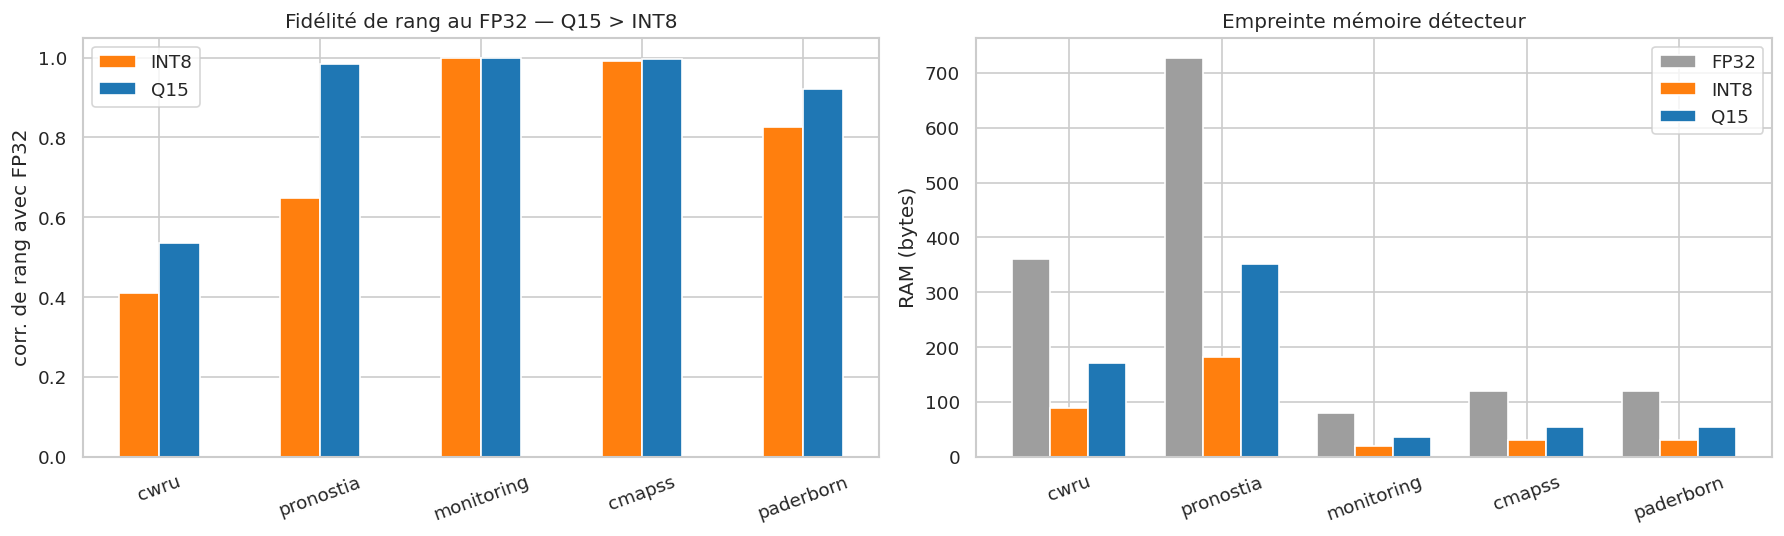

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
ax1.bar(x - w/2, q["corr_int8"], w, label="INT8", color="#ff7f0e")
ax1.bar(x + w/2, q["corr_q15"],  w, label="Q15",  color="#1f77b4")
ax1.set_xticks(x); ax1.set_xticklabels(dsets, rotation=20)
ax1.set_ylabel("corr. de rang avec FP32"); ax1.set_ylim(0, 1.05)
ax1.set_title("Fidélité de rang au FP32 — Q15 > INT8"); ax1.legend()

ax2.bar(x - w, q["ram_fp32"], w, label="FP32", color="#9e9e9e")
ax2.bar(x,     q["ram_int8"], w, label="INT8", color="#ff7f0e")
ax2.bar(x + w, q["ram_q15"],  w, label="Q15",  color="#1f77b4")
ax2.set_xticks(x); ax2.set_xticklabels(dsets, rotation=20)
ax2.set_ylabel("RAM (bytes)"); ax2.set_title("Empreinte mémoire détecteur"); ax2.legend()
plt.tight_layout(); plt.show()

### B.3 Parité board NUCLEO-F439ZI (S3408)

Firmware `maha_q15` (flag `0xF0`) : déquant → distance FP32 sur FPU → parité bit-à-bit avec Python.

Parité board ↔ PC :
  dataset  n_compared  parity_rate  max_score_abs_error  latency_us_p50  bss_bytes  gap2_ok
   cmapss         300          1.0             0.000010             5.0     105036     True
pronostia         300          1.0             0.001524             5.0     105036     True


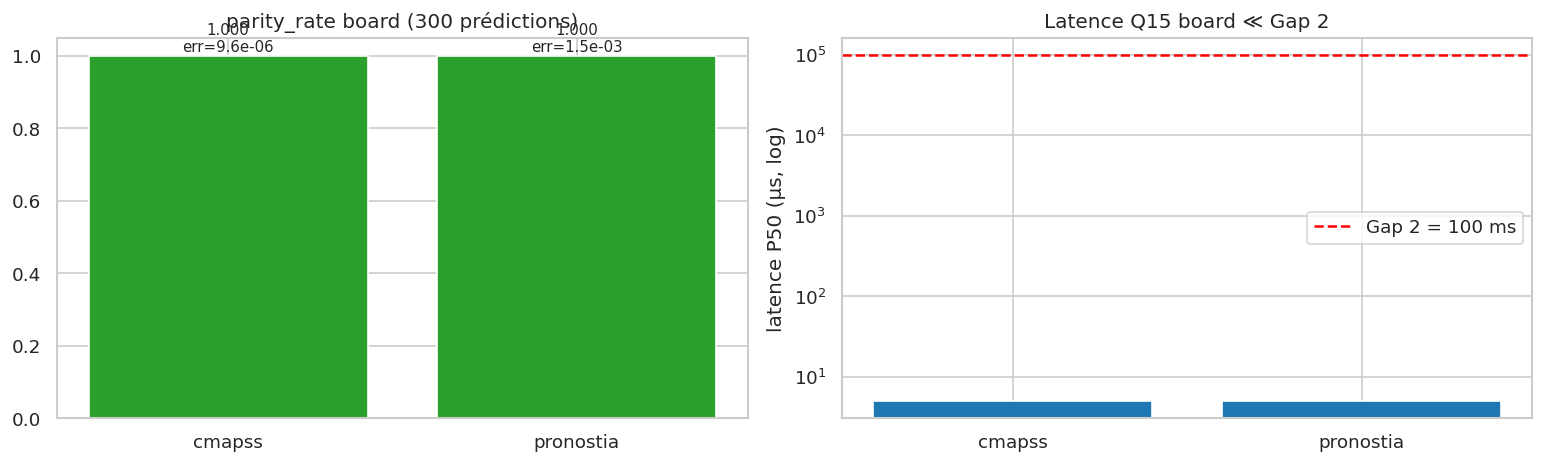

In [9]:
bq = pd.DataFrame(json.loads((EXP / "exp_S34_board_maha_q15" / "summary.json").read_text())["datasets"])
print("Parité board ↔ PC :")
print(bq[["dataset", "n_compared", "parity_rate", "max_score_abs_error",
          "latency_us_p50", "bss_bytes", "gap2_ok"]].to_string(index=False))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar(bq["dataset"], bq["parity_rate"], color="#2ca02c")
ax1.set_ylim(0, 1.05); ax1.set_title("parity_rate board (300 prédictions)")
for i, (pr, e) in enumerate(zip(bq["parity_rate"], bq["max_score_abs_error"])):
    ax1.text(i, pr + 0.01, f"{pr:.3f}\nerr={e:.1e}", ha="center", fontsize=9)
ax2.bar(bq["dataset"], bq["latency_us_p50"], color="#1f77b4")
ax2.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax2.set_yscale("log"); ax2.set_ylabel("latence P50 (µs, log)")
ax2.set_title("Latence Q15 board ≪ Gap 2"); ax2.legend()
plt.tight_layout(); plt.show()

## Conclusion

- **Streaming (A)** : marge temps-réel large sur toute la grille rate × stride (aucune saturation
  observée) ; le débit demandé reste très en-dessous de la capacité d'inférence. Le coût `.bss` du
  buffer croît linéairement avec la fenêtre `W` (= W × 16 × 4 B).
- **Q15 (B)** : Q15 **recouvre l'AUROC** là où l'INT8 collapse (Pronostia ΔAUROC −0.113 → +0.013 ;
  CMAPSS +0.005), grâce à une **fidélité de rang** systématiquement supérieure à l'INT8. Sur très
  grande dynamique (Paderborn/CWRU dégénérés) l'AUROC absolue reste limitée par `mu_` qui demeure
  INT8 — piste future `mu_` Q15.
- **Parité board = 1.000** (300/300 prédictions, `max_score_abs_error` ~1e-5..1e-3) ; latence P50
  ≈ 5 µs ≪ Gap 2.

*Tous les chiffres proviennent des JSON `exp_S34_*` ; aucune valeur saisie à la main.*